This Jupyter Notebook contains analysis of Coursera Courses dataset from Kaggle (https://www.kaggle.com/datasets/siddharthm1698/coursera-course-dataset?resource=download).


Importing the libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Loading the data:

In [3]:
# Importing the coursera data

coursera_data = pd.read_csv('Data/coursea_data.csv')
coursera_data.head()

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k


DATA CLEANING

Checking for data types

In [4]:
coursera_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                891 non-null    int64  
 1   course_title              891 non-null    object 
 2   course_organization       891 non-null    object 
 3   course_Certificate_type   891 non-null    object 
 4   course_rating             891 non-null    float64
 5   course_difficulty         891 non-null    object 
 6   course_students_enrolled  891 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 48.9+ KB


We dont need column "Unnamed" so let's drop it:

In [5]:
coursera_data = coursera_data.drop(columns=['Unnamed: 0'])


Column "course_students_enrolled" must be corrected because its data type is object and should be numeric.

In [6]:
def parse_enrollment(x):
    x = str(x).lower()            # make sure it's a string

    if 'k' in x:                  # example: 2.5k
        return float(x.replace('k', '')) * 1000
    if 'm' in x:                  # example: 1.2m
        return float(x.replace('m', '')) * 1_000_000

    try:
        return float(x)           # normal number
    except:
        return pd.NA              # if cannot convert

coursera_data['course_students_enrolled'] = coursera_data['course_students_enrolled'].apply(parse_enrollment)
coursera_data['course_students_enrolled'] = coursera_data['course_students_enrolled'].astype(float)

Change the title of 'course_Certificate_type':

In [7]:
coursera_data = coursera_data.rename(columns={
    'course_Certificate_type': 'course_certificate_type'
})

Final check:

In [8]:
coursera_data.head()

,course_title,course_organization,course_certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5300.0
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17000.0
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130000.0
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91000.0
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000.0


Checking for null values:

In [15]:
coursera_data.isnull().any()


course_title                False
course_organization         False
course_certificate_type     False
course_rating               False
course_difficulty           False
course_students_enrolled    False
dtype: bool

Checking if there are any duplicate values. I will check course_title, course_organization and course_Certificate_type.


In [16]:
coursera_data.duplicated(subset=['course_title', 'course_organization' , 'course_certificate_type'])

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [17]:
coursera_data.duplicated(subset=['course_title', 'course_organization','course_certificate_type']).sum()


np.int64(0)

Which of the features are numeric?


In [18]:
print(coursera_data.select_dtypes(include='number').columns)

Index(['course_rating', 'course_students_enrolled'], dtype='object')


Which of the features are categorical?


In [21]:
cat_cols = coursera_data.select_dtypes(include=['object']).columns
cat_cols

Index(['course_title', 'course_organization', 'course_certificate_type',
       'course_difficulty'],
      dtype='object')

Course_title and course_organization is not categorical so lets change the data type.

In [22]:
coursera_data['course_difficulty'] = coursera_data['course_difficulty'].astype('category')
coursera_data['course_certificate_type'] = coursera_data['course_certificate_type'].astype('category')

In [23]:
cat_cols = coursera_data.select_dtypes(include=['object']).columns
cat_cols

Index(['course_title', 'course_organization'], dtype='object')

FINDING THE OUTLIERS


Detect outliers in course_students_enrolled:

In [24]:
# Calculate IQR
Q1 = coursera_data['course_students_enrolled'].quantile(0.25)
Q3 = coursera_data['course_students_enrolled'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Filter outliers
outliers = coursera_data[
    (coursera_data['course_students_enrolled'] < lower_bound) |
    (coursera_data['course_students_enrolled'] > upper_bound)
]
outliers


Lower bound: -105500.0
Upper bound: 222500.0


,course_title,course_organization,course_certificate_type,course_rating,course_difficulty,course_students_enrolled
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000.0
6,AI For Everyone,deeplearning.ai,COURSE,4.8,Beginner,350000.0
18,Academic English: Writing,"University of California, Irvine",SPECIALIZATION,4.7,Beginner,540000.0
27,Advanced Data Science with IBM,IBM,SPECIALIZATION,4.4,Advanced,320000.0
43,An Introduction to Programming the Internet of...,"University of California, Irvine",SPECIALIZATION,4.6,Beginner,270000.0
...,...,...,...,...,...,...
816,The Singer Songwriter,Berklee College of Music,SPECIALIZATION,4.8,Beginner,320000.0
850,Using Python to Access Web Data,University of Michigan,COURSE,4.8,Mixed,310000.0
859,Web Design for Everybody: Basics of Web Develo...,University of Michigan,SPECIALIZATION,4.7,Beginner,280000.0
864,What is Data Science?,IBM,COURSE,4.7,Beginner,260000.0


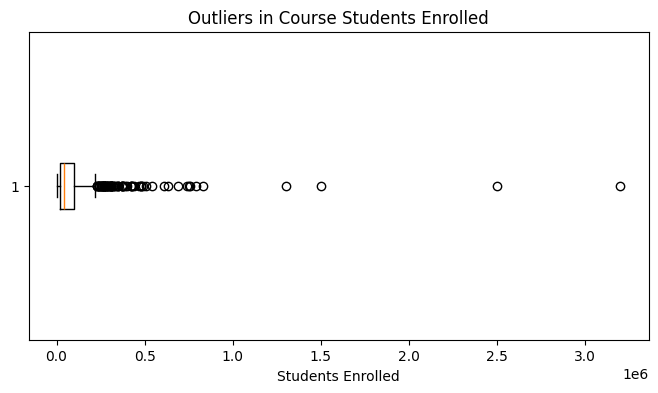

In [25]:
plt.figure(figsize=(8,4))
plt.boxplot(coursera_data['course_students_enrolled'], vert=False)
plt.title('Outliers in Course Students Enrolled')
plt.xlabel('Students Enrolled')
plt.show()

The boxplot of course students enrolled shows that most Coursera courses have few students, while a few courses are extremely popular and have very large enrollments. The main box on the left represents typical courses and the dots stretching far to the right are outliers with hundreds of thousands or even millions of learners. This means that only a small number of courses attract most of the students, while the majority have much smaller audiences.

Detect outliers in course_rating:

In [26]:
Q1_rating = coursera_data['course_rating'].quantile(0.25)
Q3_rating = coursera_data['course_rating'].quantile(0.75)
IQR_rating = Q3_rating - Q1_rating

lower_bound_rating = Q1_rating - 1.5 * IQR_rating
upper_bound_rating = Q3_rating + 1.5 * IQR_rating

print("Lower bound:", lower_bound_rating)
print("Upper bound:", upper_bound_rating)

Lower bound: 4.299999999999999
Upper bound: 5.1


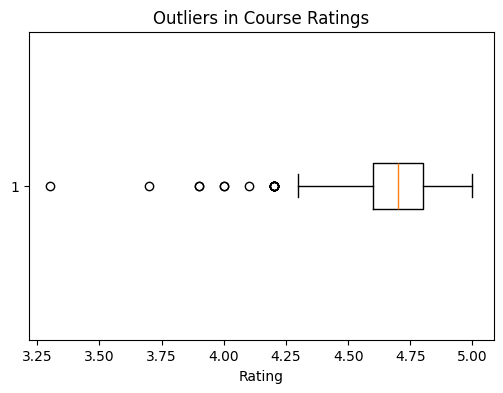

In [27]:
plt.figure(figsize=(6,4))
plt.boxplot(coursera_data['course_rating'], vert=False)
plt.title('Outliers in Course Ratings')
plt.xlabel('Rating')
plt.show()

The boxplot of course ratings shows that most Coursera courses receive high ratings, with the majority between 4.3 and 5.0. The median rating is around 4.7, indicating that learners generally rate courses very positively. However, a few courses are below this range with ratings between 3.3 and 4.2, appearing as outliers on the left side of the plot. These outliers represent courses that are rated significantly lower than the average, suggesting potential issues such as less engaging content, outdated materials or poor alignment with learner expectations.

EXPLORATORY DATA ANALYSIS


How many courses are there in total?

In [28]:
print (coursera_data.shape[0])


891


How many unique organizations offer courses?

In [29]:
print (coursera_data['course_organization'].nunique())


154


What are the different certificate types available?

In [31]:
print(coursera_data['course_certificate_type'].unique())


['SPECIALIZATION', 'COURSE', 'PROFESSIONAL CERTIFICATE']
Categories (3, object): ['COURSE', 'PROFESSIONAL CERTIFICATE', 'SPECIALIZATION']


In [32]:
cert_counts = coursera_data['course_certificate_type'].value_counts()
print(cert_counts)

course_certificate_type
COURSE                      582
SPECIALIZATION              297
PROFESSIONAL CERTIFICATE     12
Name: count, dtype: int64


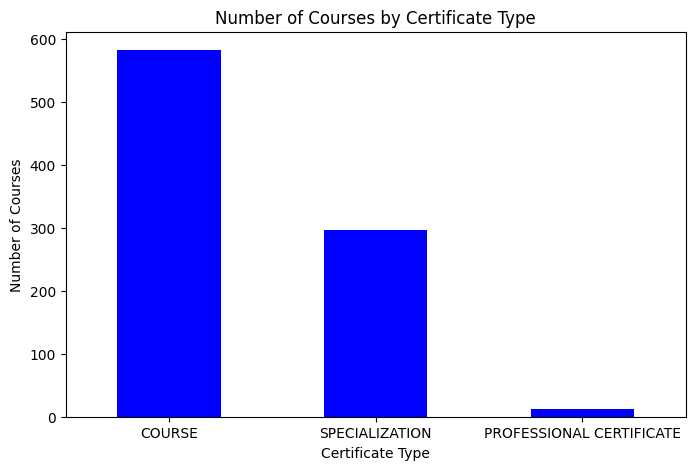

In [33]:
plt.figure(figsize=(8,5))
cert_counts.plot(kind='bar', color='blue')

plt.title('Number of Courses by Certificate Type')
plt.xlabel('Certificate Type')
plt.ylabel('Number of Courses')
plt.xticks(rotation=0)
plt.show()

What are the different difficulty levels, and how many courses fall into each?

In [36]:
print (coursera_data['course_difficulty'].unique())


['Beginner', 'Intermediate', 'Mixed', 'Advanced']
Categories (4, object): ['Advanced', 'Beginner', 'Intermediate', 'Mixed']


In [38]:
print (coursera_data['course_difficulty'].value_counts())


course_difficulty
Beginner        487
Intermediate    198
Mixed           187
Advanced         19
Name: count, dtype: int64


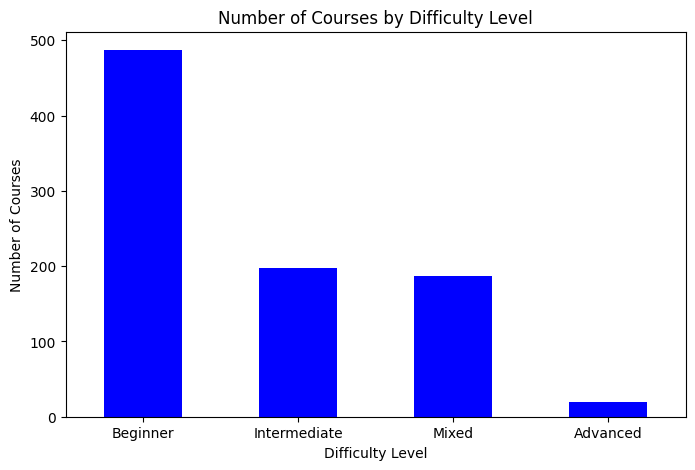

In [39]:
plt.figure(figsize=(8,5))
difficulty_counts.plot(kind='bar', color='blue')

plt.title('Number of Courses by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Number of Courses')
plt.xticks(rotation=0)
plt.show()

The dataset includes 891 courses from 154 organizations, showing a wide variety of content on Coursera. Most are individual courses (582), followed by specializations (297) and a few professional certificates (12). The majority of courses are aimed at beginners (487), with fewer intermediate (198) and mixed-level (187) options and only 19 advanced courses. Overall, Coursera focuses mainly on introductory and intermediate-level learning.

Summary statistics:

In [40]:
# Summary for course_rating
rating_mean = coursera_data['course_rating'].mean()
rating_median = coursera_data['course_rating'].median()
rating_min = coursera_data['course_rating'].min()
rating_max = coursera_data['course_rating'].max()

print("Course Rating:")
print(f"Average (mean): {rating_mean:.2f}")
print(f"Median: {rating_median:.2f}")
print(f"Minimum: {rating_min}")
print(f"Maximum: {rating_max}")

# Summary for course_students_enrolled
enroll_mean = coursera_data['course_students_enrolled'].mean()
enroll_median = coursera_data['course_students_enrolled'].median()
enroll_min = coursera_data['course_students_enrolled'].min()
enroll_max = coursera_data['course_students_enrolled'].max()

print("Course Students Enrolled:")
print(f"Average (mean): {enroll_mean:,.0f}")
print(f"Median: {enroll_median:,.0f}")
print(f"Minimum: {enroll_min:,.0f}")
print(f"Maximum: {enroll_max:,.0f}")

Course Rating:
Average (mean): 4.68
Median: 4.70
Minimum: 3.3
Maximum: 5.0
Course Students Enrolled:
Average (mean): 90,552
Median: 42,000
Minimum: 1,500
Maximum: 3,200,000


Distribution of course ratings

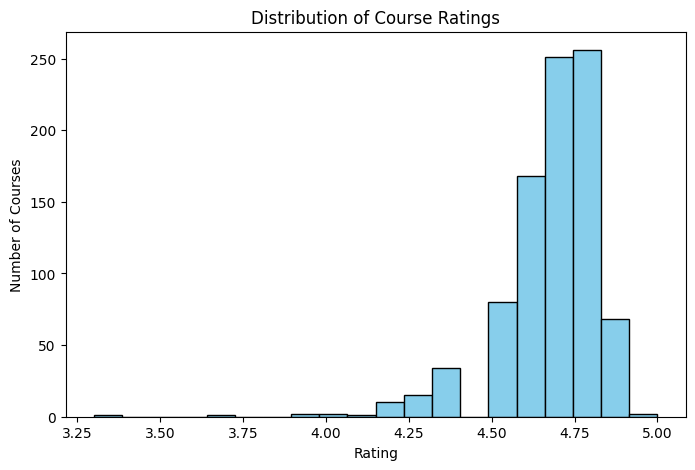

In [41]:
plt.figure(figsize=(8,5))
plt.hist(coursera_data['course_rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Courses')
plt.show()

Distribution of course enrollments

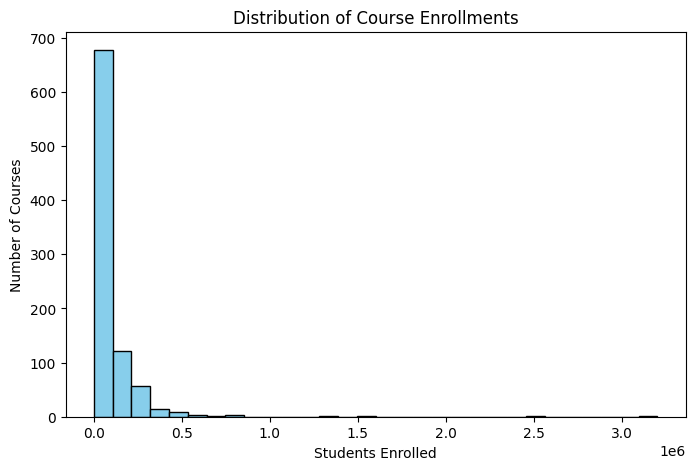

In [42]:
plt.figure(figsize=(8,5))
plt.hist(coursera_data['course_students_enrolled'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Course Enrollments')
plt.xlabel('Students Enrolled')
plt.ylabel('Number of Courses')
plt.show()

The analysis shows that Coursera courses have an average rating of 4.68 and a median of 4.7, indicating that most learners rate their courses very highly. Scores ranging from 3.3 to 5.0. The average number of students enrolled is about 90,500, but the median is 42,000, showing that a few extremely popular courses have much higher enrollments than most others. The charts show that most courses receive high ratings, while enrollments are highly uneven—only a few courses attract most of the students.

Which organizations have the most courses?

course_organization
University of Pennsylvania                    59
University of Michigan                        41
Google Cloud                                  34
Duke University                               28
Johns Hopkins University                      28
University of California, Irvine              27
IBM                                           22
University of Illinois at Urbana-Champaign    22
University of California, Davis               21
University of Colorado Boulder                19
Name: count, dtype: int64


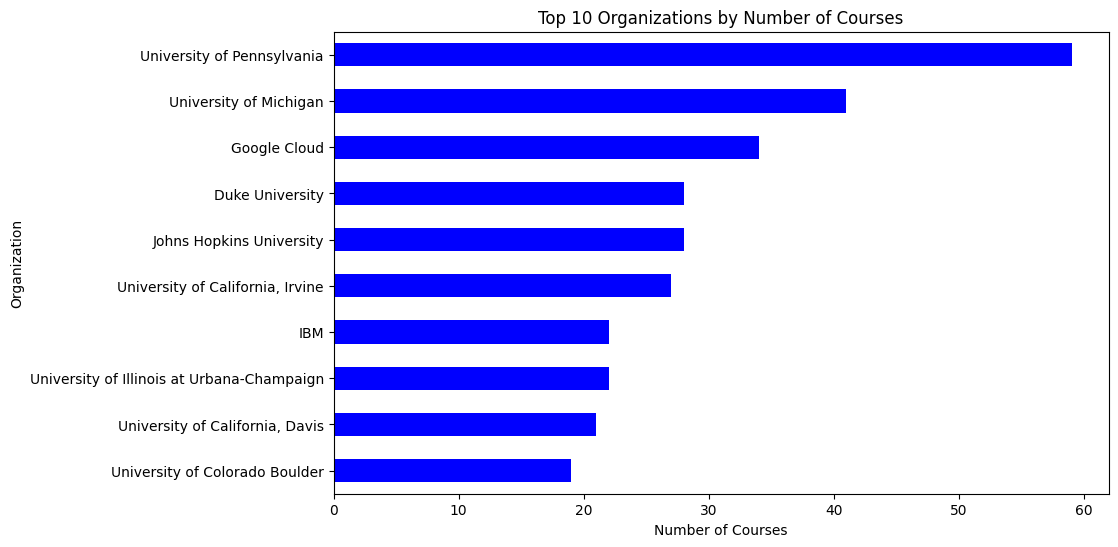

In [43]:
# Top 10 organizations by number of courses
top_orgs = coursera_data['course_organization'].value_counts().head(10)
print(top_orgs)
plt.figure(figsize=(10,6))
top_orgs.plot(kind='barh', color='blue')
plt.title('Top 10 Organizations by Number of Courses')
plt.xlabel('Number of Courses')
plt.ylabel('Organization')
plt.gca().invert_yaxis()
plt.show()

Which certificate type is most common?

course_certificate_type
COURSE                      582
SPECIALIZATION              297
PROFESSIONAL CERTIFICATE     12
Name: count, dtype: int64


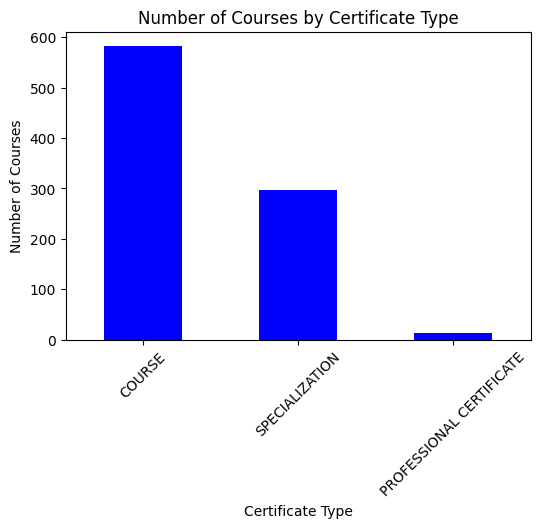

In [44]:
cert_counts = coursera_data['course_certificate_type'].value_counts()
print(cert_counts)

plt.figure(figsize=(6,4))
cert_counts.plot(kind='bar', color='blue')
plt.title('Number of Courses by Certificate Type')
plt.xlabel('Certificate Type')
plt.ylabel('Number of Courses')
plt.xticks(rotation=45)
plt.show()

Which difficulty level is most popular among learners?

course_difficulty
Beginner        487
Intermediate    198
Mixed           187
Advanced         19
Name: count, dtype: int64


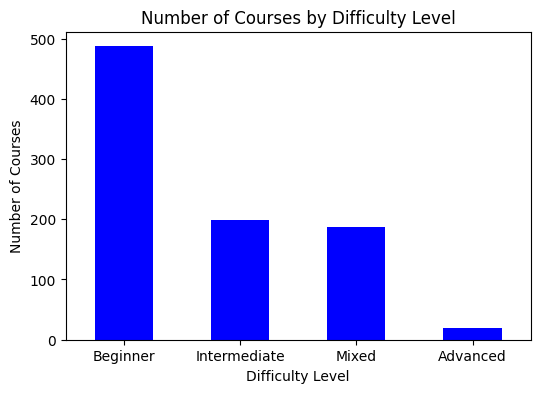

In [45]:
difficulty_counts = coursera_data['course_difficulty'].value_counts()
print(difficulty_counts)

plt.figure(figsize=(6,4))
difficulty_counts.plot(kind='bar', color='blue')
plt.title('Number of Courses by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Number of Courses')
plt.xticks(rotation=0)
plt.show()

Do some organizations focus more on a particular difficulty level or certificate type?

In [46]:
# to compare organization vs difficulty
org_difficulty = pd.crosstab(coursera_data['course_organization'], coursera_data['course_difficulty'])

# to compare organization vs certificate type
org_certificate = pd.crosstab(coursera_data['course_organization'], coursera_data['course_certificate_type'])

# Display top 10 organizations by total courses and their breakdowns
org_difficulty_top10 = org_difficulty.loc[top_orgs.index]
org_certificate_top10 = org_certificate.loc[top_orgs.index]

print("Top 10 organizations by difficulty level:")
display(org_difficulty_top10)

print("Top 10 organizations by certificate type:")
display(org_certificate_top10)

Top 10 organizations by difficulty level:


course_difficulty,Advanced,Beginner,Intermediate,Mixed
course_organization,,,,
University of Pennsylvania,0,28,5,26
University of Michigan,0,19,10,12
Google Cloud,2,8,24,0
Duke University,1,16,1,10
Johns Hopkins University,0,17,3,8
"University of California, Irvine",1,15,5,6
IBM,2,16,4,0
University of Illinois at Urbana-Champaign,0,7,10,5
"University of California, Davis",0,14,4,3


Top 10 organizations by certificate type:


course_certificate_type,COURSE,PROFESSIONAL CERTIFICATE,SPECIALIZATION
course_organization,,,
University of Pennsylvania,44,0,15
University of Michigan,30,0,11
Google Cloud,17,2,15
Duke University,22,0,6
Johns Hopkins University,17,0,11
"University of California, Irvine",12,1,14
IBM,13,3,6
University of Illinois at Urbana-Champaign,10,0,12
"University of California, Davis",11,0,10


The analysis shows that the University of Pennsylvania offers the most courses on Coursera (59), followed by the University of Michigan (41) and Google Cloud (34). The most common certificate type is COURSE (582), followed by SPECIALIZATION (297), while PROFESSIONAL CERTIFICATES (12) make up a very small portion. In terms of difficulty, most courses are Beginner level (487), with fewer Intermediate (198), Mixed (187), and only 19 Advanced courses. Looking at the top organizations, most of them focus mainly on beginner and mixed-level courses and primarily offer individual courses and specializations. This suggests that Coursera’s partner institutions concentrate on entry-level, accessible learning paths and aim to reach a wide audience.

Is there a relationship between course rating and number of students enrolled?

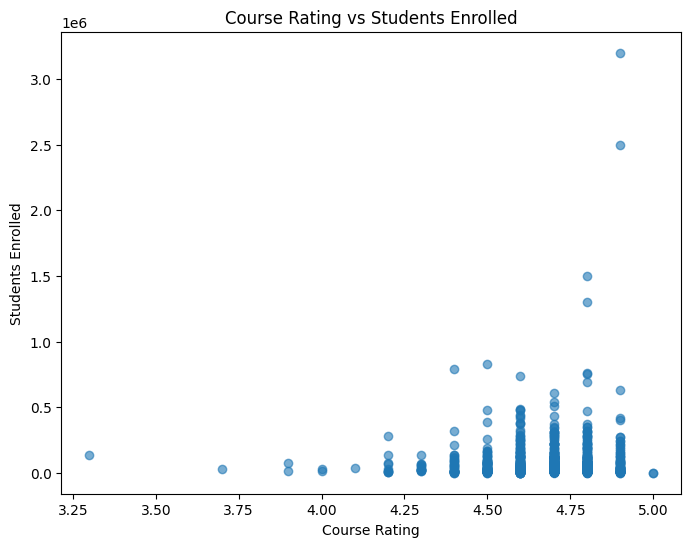

Correlation between rating and enrollments: 0.07


In [48]:
plt.figure(figsize=(8,6))
plt.scatter(coursera_data['course_rating'], coursera_data['course_students_enrolled'], alpha=0.6)
#alpha=0.6 makes points slightly transparent
plt.title('Course Rating vs Students Enrolled')
plt.xlabel('Course Rating')
plt.ylabel('Students Enrolled')
plt.show()

# Correlation coefficient
corr = coursera_data['course_rating'].corr(coursera_data['course_students_enrolled'])
print(f"Correlation between rating and enrollments: {corr:.2f}")

Correlation is very close to zero, which means there is no meaningful relationship between a course’s rating and the number of students enrolled.

Do easier courses (Beginner level) have higher enrollments than harder ones?

course_difficulty
Mixed           133633.0
Beginner         81975.0
Intermediate     73264.0
Advanced         66547.0
Name: course_students_enrolled, dtype: float64


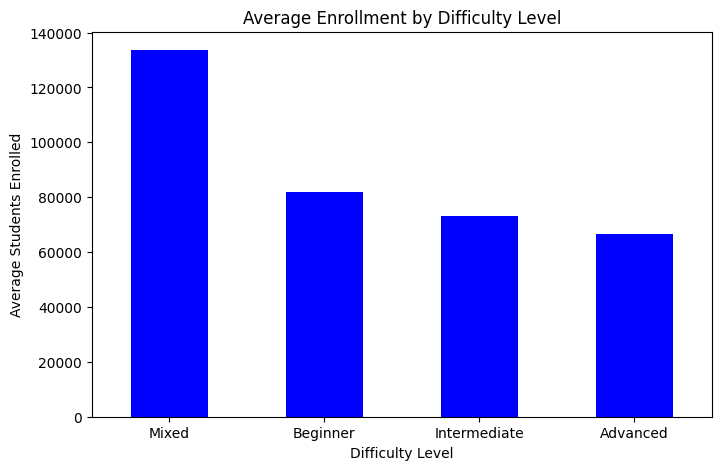

In [49]:
# Groupby with observed=True to remove FutureWarning
difficulty_enroll = (
    coursera_data
    .groupby('course_difficulty', observed=True)['course_students_enrolled']
    .mean()
    .sort_values(ascending=False)
)

# Print rounded values
print(difficulty_enroll.round(0))

# Plot
plt.figure(figsize=(8,5))
difficulty_enroll.plot(kind='bar', color='blue')
plt.title('Average Enrollment by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Average Students Enrolled')
plt.xticks(rotation=0)
plt.show()

Does certificate type affect enrollments or ratings?

                          course_students_enrolled  course_rating
course_certificate_type                                          
PROFESSIONAL CERTIFICATE             190700.000000       4.700000
SPECIALIZATION                        91791.919192       4.618182
COURSE                                87854.467354       4.707045


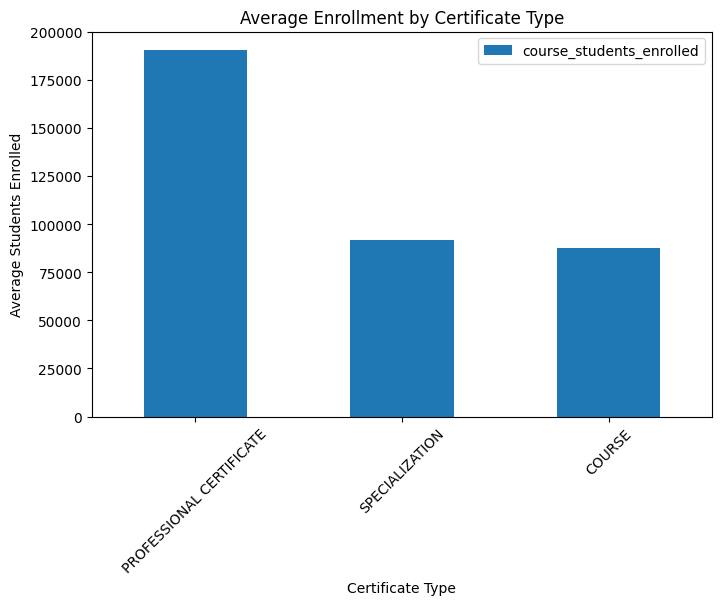

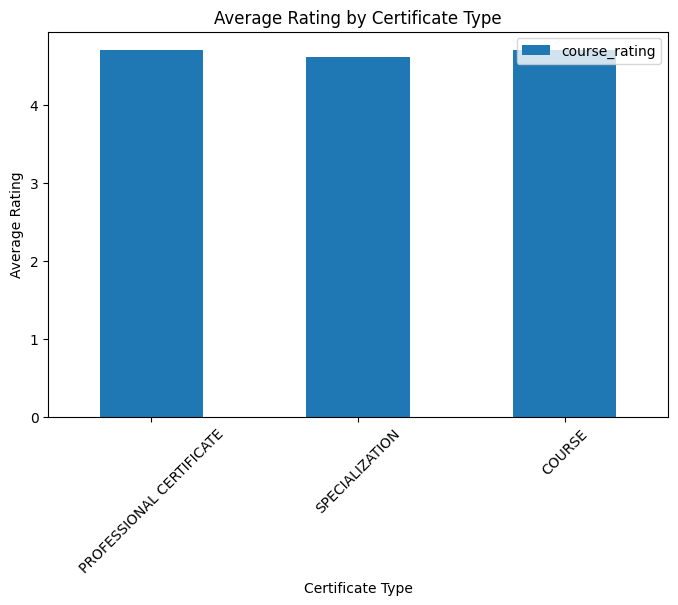

In [50]:
# Average enrollment and rating by certificate type
cert_summary = (
    coursera_data
    .groupby('course_certificate_type', observed=True)[['course_students_enrolled', 'course_rating']]
    .mean()
    .sort_values(by='course_students_enrolled', ascending=False)
)

print(cert_summary)

# Plot: Average Enrollment
cert_summary[['course_students_enrolled']].plot(kind='bar', figsize=(8,5))
plt.title('Average Enrollment by Certificate Type')
plt.xlabel('Certificate Type')
plt.ylabel('Average Students Enrolled')
plt.xticks(rotation=45)
plt.show()

# Plot: Average Rating
cert_summary[['course_rating']].plot(kind='bar', figsize=(8,5))
plt.title('Average Rating by Certificate Type')
plt.xlabel('Certificate Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

Are organizations with more courses also getting higher average ratings or enrollments?

In [51]:
# Calculate averages per organization
org_summary = coursera_data.groupby('course_organization')[['course_rating', 'course_students_enrolled']].mean()
org_summary['total_courses'] = coursera_data['course_organization'].value_counts()

# Correlations
corr_courses_rating = org_summary['total_courses'].corr(org_summary['course_rating'])
corr_courses_enroll = org_summary['total_courses'].corr(org_summary['course_students_enrolled'])

print(f"Correlation between number of courses and average rating: {corr_courses_rating:.2f}")
print(f"Correlation between number of courses and average enrollment: {corr_courses_enroll:.2f}")

Correlation between number of courses and average rating: -0.00
Correlation between number of courses and average enrollment: 0.41


The results show that there is almost no link between a course’s rating and how many students enroll (correlation = 0.07). Mixed-level courses have the highest average enrollments (about 133 K), followed by Beginner ones (82 K), while Intermediate and Advanced courses attract fewer learners. This means students prefer easier or more flexible courses. Among certificate types, Professional Certificates have the most students on average (around 191 K), but ratings stay similar for all types at about 4.6–4.7. Organizations that offer more courses do not get higher ratings, but they usually have more total enrollments (correlation = 0.41).

Courses with the highest and lowest ratings:

In [52]:
# Highest-rated courses
highest_rated = coursera_data.sort_values(by='course_rating', ascending=False).head(10)
print("Top 10 highest-rated courses:")
display(highest_rated[['course_title', 'course_organization', 'course_rating']])

# Lowest-rated courses
lowest_rated = coursera_data.sort_values(by='course_rating', ascending=True).head(10)
print("\nBottom 10 lowest-rated courses:")
display(lowest_rated[['course_title', 'course_organization', 'course_rating']])

Top 10 highest-rated courses:


,course_title,course_organization,course_rating
432,Infectious Disease Modelling,Imperial College London,5.0
251,El Abogado del Futuro: Legaltech y la Transfor...,Universidad Austral,5.0
124,COVID-19 Contact Tracing,Johns Hopkins University,4.9
147,Compassionate Leadership Through Service Learn...,University of Colorado Boulder,4.9
102,Bugs 101: Insect-Human Interactions,University of Alberta,4.9
803,The Horse Course: Introduction to Basic Care a...,University of Florida,4.9
103,Build a Modern Computer from First Principles:...,Hebrew University of Jerusalem,4.9
754,Stories of Infection,Stanford University,4.9
807,The Oral Cavity: Portal to Health and Disease,University of Pennsylvania,4.9
684,Python Data Structures,University of Michigan,4.9



Bottom 10 lowest-rated courses:


,course_title,course_organization,course_rating
413,How To Create a Website in a Weekend! (Project...,The State University of New York,3.3
566,Machine Learning and Reinforcement Learning in...,New York University,3.7
569,Machine Learning for Trading,Google Cloud,3.9
873,iOS App Development with Swift,University of Toronto,3.9
598,Mathematics for Machine Learning: PCA,Imperial College London,4.0
522,"Introduction to Trading, Machine Learning & GCP",New York Institute of Finance,4.0
414,How to Start Your Own Business,Michigan State University,4.1
844,Unity XR: How to Build AR and VR Apps,Unity,4.2
590,Mastering Data Analysis in Excel,Duke University,4.2
445,Instructional Design Foundations and Applications,University of Illinois at Urbana-Champaign,4.2


Courses with the highest and lowest enrollments:

In [53]:
# Most popular courses
most_enrolled = coursera_data.sort_values(by='course_students_enrolled', ascending=False).head(10)
print("Top 10 most enrolled courses:")
display(most_enrolled[['course_title', 'course_organization', 'course_students_enrolled']])

# Least popular courses
least_enrolled = coursera_data.sort_values(by='course_students_enrolled', ascending=True).head(10)
print("\nBottom 10 least enrolled courses:")
display(least_enrolled[['course_title', 'course_organization', 'course_students_enrolled']])

Top 10 most enrolled courses:


,course_title,course_organization,course_students_enrolled
564,Machine Learning,Stanford University,3200000.0
815,The Science of Well-Being,Yale University,2500000.0
688,Python for Everybody,University of Michigan,1500000.0
674,Programming for Everybody (Getting Started wit...,University of Michigan,1300000.0
196,Data Science,Johns Hopkins University,830000.0
129,Career Success,"University of California, Irvine",790000.0
261,English for Career Development,University of Pennsylvania,760000.0
765,Successful Negotiation: Essential Strategies a...,University of Michigan,750000.0
199,Data Science: Foundations using R,Johns Hopkins University,740000.0
211,Deep Learning,deeplearning.ai,690000.0



Bottom 10 least enrolled courses:


,course_title,course_organization,course_students_enrolled
251,El Abogado del Futuro: Legaltech y la Transfor...,Universidad Austral,1500.0
432,Infectious Disease Modelling,Imperial College London,1600.0
96,Blockchain Revolution in Financial Services,INSEAD,1600.0
810,The Pronunciation of American English,"University of California, Irvine",1700.0
423,"Identifying, Monitoring, and Analyzing Risk an...",(ISC)²,1700.0
406,Healthcare Law,University of Pennsylvania,1700.0
280,Esports,"University of California, Irvine",1800.0
93,Blended Language Learning: Design and Practice...,University of Colorado Boulder,1900.0
425,Implementing RPA with Cognitive Automation and...,Automation Anywhere,2200.0
459,International Security Management,Erasmus University Rotterdam,2200.0


Organizations that dominate outliers:

In [54]:
# Most frequent organizations among top 10 most enrolled courses
top_orgs_popular = most_enrolled['course_organization'].value_counts()
print("Organizations with the most popular courses:")
print(top_orgs_popular)

# Most frequent organizations among lowest-rated or least-enrolled courses
low_orgs_ratings = lowest_rated['course_organization'].value_counts()
low_orgs_enroll = least_enrolled['course_organization'].value_counts()

print("Organizations with lowest-rated courses:")
print(low_orgs_ratings)

print("Organizations with least-enrolled courses:")
print(low_orgs_enroll)

Organizations with the most popular courses:
course_organization
University of Michigan              3
Johns Hopkins University            2
Stanford University                 1
Yale University                     1
University of California, Irvine    1
University of Pennsylvania          1
deeplearning.ai                     1
Name: count, dtype: int64
Organizations with lowest-rated courses:
course_organization
The State University of New York              1
New York University                           1
Google Cloud                                  1
University of Toronto                         1
Imperial College London                       1
New York Institute of Finance                 1
Michigan State University                     1
Unity                                         1
Duke University                               1
University of Illinois at Urbana-Champaign    1
Name: count, dtype: int64
Organizations with least-enrolled courses:
course_organization
University of

The analysis shows that the highest-rated courses (4.9–5.0) come from well-known universities such as Imperial College London, Universidad Austral, Johns Hopkins University, and Stanford University, covering topics like infectious diseases, leadership, and data science. The lowest-rated courses (3.3–4.2) include subjects like web development, trading, and machine learning, offered by various institutions such as SUNY, NYU, and Google Cloud. The most popular courses by enrollment are major hits like Machine Learning by Stanford University (3.2M students) and The Science of Well-Being by Yale University (2.5M students), while less popular ones, such as El Abogado del Futuro and Infectious Disease Modelling, have under 2,000 students. The University of Michigan and Johns Hopkins University dominate among the most enrolled courses, while University of California, Irvine appears most often among the least enrolled. Overall, highly rated and popular courses tend to come from globally recognized universities, showing their strong influence on Coursera’s platform.

Organizations by their average rating and average enrollment

In [55]:
# Calculate average rating and enrollment per organization
org_rank = coursera_data.groupby('course_organization')[['course_rating', 'course_students_enrolled']].mean()

# Sort by average rating
top_orgs_rating = org_rank.sort_values(by='course_rating', ascending=False).head(10)
print("Top 10 organizations by average rating:")
display(top_orgs_rating)

# Sort by average enrollment
top_orgs_enroll = org_rank.sort_values(by='course_students_enrolled', ascending=False).head(10)
print("\nTop 10 organizations by average enrollment:")
display(top_orgs_enroll)

Top 10 organizations by average rating:


,course_rating,course_students_enrolled
course_organization,,
Crece con Google,4.900000,8800.0
Google - Spectrum Sharing,4.900000,210000.0
"Nanyang Technological University, Singapore",4.900000,47000.0
London Business School,4.900000,57000.0
Universidade Estadual de Campinas,4.900000,17000.0
ScrumTrek,4.900000,12000.0
Hebrew University of Jerusalem,4.900000,95000.0
Universidade de São Paulo,4.866667,68500.0
The University of Chicago,4.850000,84000.0



Top 10 organizations by average enrollment:


,course_rating,course_students_enrolled
course_organization,,
Stanford University,4.768750,303375.000000
Yale University,4.817647,232470.588235
McMaster University,4.800000,230000.000000
Google - Spectrum Sharing,4.900000,210000.000000
Ludwig-Maximilians-Universität München (LMU),4.750000,192500.000000
École Polytechnique,4.800000,190000.000000
University of Michigan,4.729268,181407.317073
Georgia Institute of Technology,4.660000,181300.000000
deeplearning.ai,4.743750,178962.500000


Top 10 most popular courses and their organizations:

In [56]:
popular_courses = coursera_data.sort_values(by='course_students_enrolled', ascending=False).head(10)
print("Top 10 most popular courses:")
display(popular_courses[['course_title', 'course_organization', 'course_students_enrolled']])

Top 10 most popular courses:


,course_title,course_organization,course_students_enrolled
564,Machine Learning,Stanford University,3200000.0
815,The Science of Well-Being,Yale University,2500000.0
688,Python for Everybody,University of Michigan,1500000.0
674,Programming for Everybody (Getting Started wit...,University of Michigan,1300000.0
196,Data Science,Johns Hopkins University,830000.0
129,Career Success,"University of California, Irvine",790000.0
261,English for Career Development,University of Pennsylvania,760000.0
765,Successful Negotiation: Essential Strategies a...,University of Michigan,750000.0
199,Data Science: Foundations using R,Johns Hopkins University,740000.0
211,Deep Learning,deeplearning.ai,690000.0


Average ratings by difficulty level:

course_difficulty
Mixed           4.71
Beginner        4.68
Intermediate    4.65
Advanced        4.60
Name: course_rating, dtype: float64


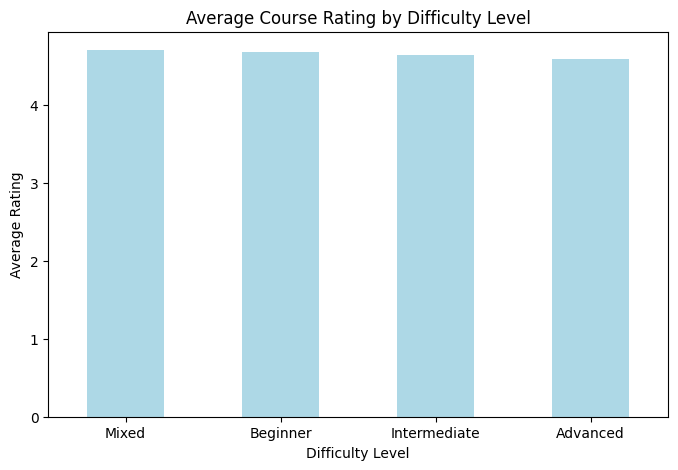

In [57]:
# Average rating by difficulty
difficulty_ratings = (
    coursera_data
    .groupby('course_difficulty', observed=True)['course_rating']
    .mean()
    .sort_values(ascending=False)
)

print(difficulty_ratings.round(2))

# Visualize
difficulty_ratings.plot(kind='bar', color='lightblue', figsize=(8,5))
plt.title('Average Course Rating by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()


Explore if mixed difficulty courses perform differently from single-level ones:

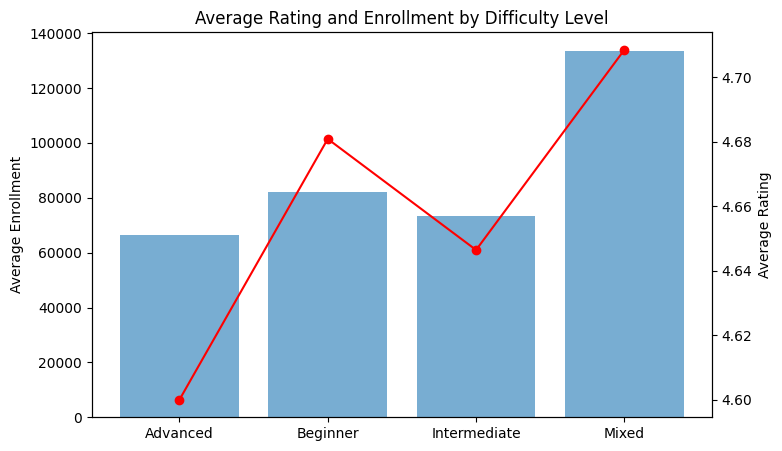

In [59]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(difficulty_compare.index,
        difficulty_compare['course_students_enrolled'],
        alpha=0.6)
ax1.set_ylabel('Average Enrollment')

ax2 = ax1.twinx()
ax2.plot(difficulty_compare.index,
         difficulty_compare['course_rating'],
         color='red', marker='o')
ax2.set_ylabel('Average Rating')

plt.title('Average Rating and Enrollment by Difficulty Level')
plt.xticks(rotation=0)
plt.show()

The analysis shows that several organizations maintain very high average ratings, with Crece con Google, Hebrew University of Jerusalem, and London Business School all scoring around 4.9, showing consistently strong learner satisfaction. When ranked by average enrollment, institutions like Stanford University, Yale University, and McMaster University lead with average enrollments above 200,000, indicating wide course popularity. The top 10 most popular courses include global hits such as Machine Learning (Stanford), The Science of Well-Being (Yale), and Python for Everybody (University of Michigan), each enrolling hundreds of thousands to millions of learners. Comparing difficulty levels, Mixed-level courses have the highest ratings (4.71) and enrollments (133K on average), followed by Beginner courses, while Advanced ones receive slightly lower ratings (4.6) and smaller audiences. This suggests that learners prefer accessible, flexible courses designed for a broad range of skill levels.

OVERALL INSIGHTS:

The analysis of 891 Coursera courses shows that most are beginner-friendly individual courses, offered by 154 different organizations. Learners generally rate courses very highly, with an average rating of 4.68, indicating strong overall satisfaction. However, enrollments are very uneven — while the median is around 42,000, a few highly popular courses attract hundreds of thousands or even millions of students.

Most top-performing organizations, such as University of Pennsylvania, University of Michigan, Stanford University, and Johns Hopkins University, consistently appear among the highest-rated and most-enrolled courses. Courses like Machine Learning (Stanford) and The Science of Well-Being (Yale) stand out as most interesting to students.

When comparing course types, Professional Certificates attract the largest average enrollments, while regular Courses and Specializations maintain similar high ratings. In terms of difficulty, Mixed and Beginner courses receive the best ratings and highest enrollments, showing that learners prefer accessible content.

Overall, Coursera’s catalog is dominated by high-quality, entry-level courses created by leading universities, with a few massively popular ones driving the majority of engagement. The platform’s success is built on broad accessibility, trusted institutions, and consistently positive learning experiences.

SUGGESTIONS AND RECOMMENDATIONS:

- Promote top-rated institutions and courses.
- Expand beginner and mixed-level content.
- Support underperforming courses.
- Increase visibility of Professional Certificates.
- Encourage variety in advanced-level offerings.
- Personalize recommendations — suggesting beginner learners move into mixed-level content.